In [ ]:
import zipfile, os

# path where you uploaded your zip file
zip_path = "/content/DL_Assignment1_Dataset.zip"
extract_path = "/content/Dataset"

# unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted dataset to:", extract_path)
print(os.listdir(extract_path))  # should show ['annotations', 'images']


Extracted dataset to: /content/Dataset
['Dataset']


In [ ]:
base_path = "/content/Dataset/Dataset/Dataset"
ANN_DIR = os.path.join(base_path, "annotations")
IMG_DIR = os.path.join(base_path, "images")

print("Annotations:", os.listdir(ANN_DIR)[:5])
print("Images:", len(os.listdir(IMG_DIR)))


Annotations: ['4004_val.npy', '3039_exp.npy', '698_aro.npy', '2950_lnd.npy', '899_val.npy']
Images: 3999


In [ ]:
import numpy as np
import os

ANN_DIR = "/content/Dataset/Dataset/Dataset/annotations"
IMG_DIR = "/content/Dataset/Dataset/Dataset/images"

labels, valence, arousal, landmarks, image_files = [], [], [], [], []

for img_file in os.listdir(IMG_DIR):
    if not img_file.endswith(".jpg"):
        continue
    img_id = os.path.splitext(img_file)[0]  # e.g. "9" from "9.jpg"

    exp_file = os.path.join(ANN_DIR, f"{img_id}_exp.npy")
    val_file = os.path.join(ANN_DIR, f"{img_id}_val.npy")
    aro_file = os.path.join(ANN_DIR, f"{img_id}_aro.npy")
    lnd_file = os.path.join(ANN_DIR, f"{img_id}_lnd.npy")

    # Only keep if all 4 annotations exist
    if all(os.path.exists(f) for f in [exp_file, val_file, aro_file, lnd_file]):
        labels.append(np.load(exp_file))
        valence.append(np.load(val_file))
        arousal.append(np.load(aro_file))
        landmarks.append(np.load(lnd_file))
        image_files.append(os.path.join(IMG_DIR, img_file))

labels    = np.array(labels)
valence   = np.array(valence)
arousal   = np.array(arousal)
landmarks = np.array(landmarks)
image_files = np.array(image_files)

print("Shapes:", labels.shape, valence.shape, arousal.shape, landmarks.shape, len(image_files))

# save the cleaned dataset
np.savez_compressed(
    "/content/annotations_merged1.npz",
    labels=labels,
    valence=valence,
    arousal=arousal,
    landmarks=landmarks,
    image_files=image_files
)
print("✅ Saved cleaned dataset to /content/annotations_merged1.npz")


Shapes: (3999,) (3999,) (3999,) (3999, 136) 3999
✅ Saved cleaned dataset to /content/annotations_merged1.npz


In [ ]:
!pip install -q tensorflow==2.15.0


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

# Load merged dataset
data = np.load("annotations_merged1.npz", allow_pickle=True)
labels = data["labels"]
valence = data["valence"]
arousal = data["arousal"]
landmarks = data["landmarks"]
image_files = data["image_files"]

print("Dataset shapes:", labels.shape, valence.shape, arousal.shape, landmarks.shape, len(image_files))

# --- Train/Test split (70/30) ---
train_idx, test_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.30,           # 30% test
    stratify=labels,          # keep label balance
    random_state=42
)

def make_dataset(idxs, batch_size=32, shuffle=True):
    img_paths = image_files[idxs]
    lbls = labels[idxs].astype("int32")
    va = np.stack([valence[idxs], arousal[idxs]], axis=1).astype("float32")
    lmarks = landmarks[idxs].astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((img_paths, lmarks, lbls, va))

    def _load_fn(path, lmarks, lbl, va):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = tf.cast(img, tf.float32) / 255.0
        return ({"image": img, "landmarks": lmarks},
                {"expression": lbl, "va": va})

    ds = ds.map(_load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(idxs))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Create datasets
train_ds = make_dataset(train_idx, batch_size=32, shuffle=True)
test_ds  = make_dataset(test_idx, batch_size=32, shuffle=False)

# Quick check
for x, y in train_ds.take(1):
    print("Image batch:", x["image"].shape)
    print("Landmarks batch:", x["landmarks"].shape)
    print("Labels batch:", y["expression"].shape)
    print("Valence+Arousal batch:", y["va"].shape)


Dataset shapes: (3999,) (3999,) (3999,) (3999, 136) 3999
Image batch: (32, 224, 224, 3)
Landmarks batch: (32, 136)
Labels batch: (32,)
Valence+Arousal batch: (32, 2)


In [ ]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def build_multitask_model(image_shape=(224,224,3), landmark_shape=(136,)):
    # Backbone CNN
    base_cnn = MobileNetV2(include_top=False, input_shape=image_shape, weights="imagenet")
    base_cnn.trainable = False  # freeze backbone for first stage

    # Image branch
    img_in = layers.Input(shape=image_shape, name="image")
    x = base_cnn(img_in, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Landmark branch
    lm_in = layers.Input(shape=landmark_shape, name="landmarks")
    l = layers.Dense(128, activation="relu")(lm_in)
    l = layers.Dropout(0.3)(l)
    l = layers.Dense(64, activation="relu")(l)

    # Merge
    combined = layers.Concatenate()([x, l])
    combined = layers.Dense(256, activation="relu")(combined)
    combined = layers.Dropout(0.4)(combined)

    # Expression head (classification)
    exp = layers.Dense(128, activation="relu")(combined)
    exp = layers.Dropout(0.3)(exp)
    exp_out = layers.Dense(8, activation="softmax", name="expression")(exp)

    # Valence/Arousal head (regression)
    va = layers.Dense(64, activation="relu")(combined)
    va = layers.Dropout(0.3)(va)
    va_out = layers.Dense(2, activation="tanh", name="va")(va)  # [-1,1]

    return Model(inputs=[img_in, lm_in], outputs=[exp_out, va_out])

model = build_multitask_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmarks           │ (None, 136)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     17,536 │ landmarks[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image[0][0]       │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1344)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    344,320 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expression (Dense)  │ (None, 8)         │      1,032 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ va (Dense)          │ (None, 2)         │        130 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,678,602 (10.22 MB)

 Trainable params: 420,618 (1.60 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.19.0
Num GPUs Available: 1


In [ ]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def build_multitask_model(image_shape=(224,224,3), landmark_shape=(136,)):
    # CNN backbone
    base_cnn = MobileNetV2(include_top=False, input_shape=image_shape, weights="imagenet")
    base_cnn.trainable = False  # freeze for stage 1

    # Image input
    img_in = layers.Input(shape=image_shape, name="image")
    x = base_cnn(img_in, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Landmark input
    lm_in = layers.Input(shape=landmark_shape, name="landmarks")
    l = layers.Dense(128, activation="relu")(lm_in)
    l = layers.Dropout(0.3)(l)
    l = layers.Dense(64, activation="relu")(l)

    # Merge
    combined = layers.Concatenate()([x, l])
    combined = layers.Dense(256, activation="relu")(combined)
    combined = layers.Dropout(0.4)(combined)

    # Expression head
    exp = layers.Dense(128, activation="relu")(combined)
    exp = layers.Dropout(0.3)(exp)
    exp_out = layers.Dense(8, activation="softmax", name="expression")(exp)

    # Valence/Arousal head
    va = layers.Dense(64, activation="relu")(combined)
    va = layers.Dropout(0.3)(va)
    va_out = layers.Dense(2, activation="tanh", name="va")(va)  # [-1,1]

    return Model(inputs=[img_in, lm_in], outputs=[exp_out, va_out])

model = build_multitask_model()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmarks           │ (None, 136)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     17,536 │ landmarks[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image[0][0]       │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1344)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    344,320 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     32,896 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │     16,448 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expression (Dense)  │ (None, 8)         │      1,032 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ va (Dense)          │ (None, 2)         │        130 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,678,602 (10.22 MB)

 Trainable params: 420,618 (1.60 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={
        "expression": "sparse_categorical_crossentropy",
        "va": "mse"
    },
    metrics={
        "expression": ["accuracy"],
        "va": ["mse"]
    }
)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)


Epoch 1/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 61s 362ms/step - expression_accuracy: 0.1300 - expression_loss: 8.7882 - loss: 9.7196 - va_loss: 0.9309 - va_mse: 0.9310 - val_expression_accuracy: 0.1471 - val_expression_loss: 2.0748 - val_loss: 2.2934 - val_va_loss: 0.2184 - val_va_mse: 0.2185
Epoch 2/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - expression_accuracy: 0.1363 - expression_loss: 2.0806 - loss: 2.2899 - va_loss: 0.2092 - va_mse: 0.2092 - val_expression_accuracy: 0.1765 - val_expression_loss: 2.0720 - val_loss: 2.2512 - val_va_loss: 0.1792 - val_va_mse: 0.1792
Epoch 3/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - expression_accuracy: 0.1427 - expression_loss: 2.0700 - loss: 2.2558 - va_loss: 0.1858 - va_mse: 0.1858 - val_expression_accuracy: 0.2020 - val_expression_loss: 2.0611 - val_loss: 2.2382 - val_va_loss: 0.1772 - val_va_mse: 0.1772
Epoch 4/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - expression_accuracy: 0.1653 - expression_loss: 2.0543 - loss: 2.2402 - va_loss: 0.1859 - va_mse:

**MobileNet-V2**

In [ ]:
model.get_layer("mobilenetv2_1.00_224").trainable = True
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower LR for fine-tuning
    loss={
        "expression": "sparse_categorical_crossentropy",
        "va": "mse"
    },
    metrics={
        "expression": ["accuracy"],
        "va": ["mse"]
    }
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 104s 505ms/step - expression_accuracy: 0.1760 - expression_loss: 2.9022 - loss: 3.1277 - va_loss: 0.2254 - va_mse: 0.2254 - val_expression_accuracy: 0.2451 - val_expression_loss: 2.2045 - val_loss: 2.3689 - val_va_loss: 0.1660 - val_va_mse: 0.1658
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - expression_accuracy: 0.1838 - expression_loss: 2.3079 - loss: 2.5016 - va_loss: 0.1936 - va_mse: 0.1936 - val_expression_accuracy: 0.2216 - val_expression_loss: 2.3581 - val_loss: 2.5279 - val_va_loss: 0.1717 - val_va_mse: 0.1715
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - expression_accuracy: 0.2114 - expression_loss: 2.0664 - loss: 2.2459 - va_loss: 0.1795 - va_mse: 0.1795 - val_expression_accuracy: 0.2059 - val_expression_loss: 2.3544 - val_loss: 2.5261 - val_va_loss: 0.1734 - val_va_mse: 0.1732
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - expression_accuracy: 0.2224 - expression_loss: 1.9639 - loss: 2.1313 - va_loss: 0.1673 - 

In [ ]:
results = model.evaluate(test_ds)
print("Test Results:", results)


19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 624ms/step - expression_accuracy: 0.2903 - expression_loss: 1.8411 - loss: 2.0011 - va_loss: 0.1602 - va_mse: 0.1602
Test Results: [2.0448684692382812, 1.8870837688446045, 0.15992464125156403, 0.28833332657814026, 0.15952175855636597]


In [ ]:
import numpy as np

y_true_exp, y_pred_exp = [], []
y_true_va, y_pred_va = [], []

for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    exp_pred = np.argmax(preds[0], axis=1)   # predicted classes
    va_pred = preds[1]                       # predicted valence/arousal

    y_true_exp.extend(y["expression"].numpy())
    y_pred_exp.extend(exp_pred)
    y_true_va.extend(y["va"].numpy())
    y_pred_va.extend(va_pred)

y_true_exp = np.array(y_true_exp)
y_pred_exp = np.array(y_pred_exp)
y_true_va = np.array(y_true_va)
y_pred_va = np.array(y_pred_va)


**Using Data Augmentation to Increase Accruacy from 29%**

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")


In [ ]:
def _load_fn(path, lmarks, lbl, va):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0
    img = data_augmentation(img)   # ✅ apply augmentation
    return ({"image": img, "landmarks": lmarks}, {"expression": lbl, "va": va})


In [ ]:
# Freeze backbone first (warmup stage)
model = build_multitask_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={"expression": "sparse_categorical_crossentropy", "va": "mse"},
    metrics={"expression": ["accuracy"], "va": ["mse"]}
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

# Fine-tune (unfreeze backbone)
model.get_layer("mobilenetv2_1.00_224").trainable = True
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={"expression": "sparse_categorical_crossentropy", "va": "mse"},
    metrics={"expression": ["accuracy"], "va": ["mse"]}
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)


Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 197ms/step - expression_accuracy: 0.1348 - expression_loss: 10.0812 - loss: 10.9114 - va_loss: 0.8298 - va_mse: 0.8298 - val_expression_accuracy: 0.1333 - val_expression_loss: 2.0743 - val_loss: 2.2772 - val_va_loss: 0.2029 - val_va_mse: 0.2029
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - expression_accuracy: 0.1598 - expression_loss: 2.0763 - loss: 2.2824 - va_loss: 0.2061 - va_mse: 0.2061 - val_expression_accuracy: 0.1980 - val_expression_loss: 2.0596 - val_loss: 2.2416 - val_va_loss: 0.1820 - val_va_mse: 0.1820
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - expression_accuracy: 0.1708 - expression_loss: 2.0538 - loss: 2.2391 - va_loss: 0.1853 - va_mse: 0.1853 - val_expression_accuracy: 0.2529 - val_expression_loss: 2.0174 - val_loss: 2.1928 - val_va_loss: 0.1756 - val_va_mse: 0.1756
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - expression_accuracy: 0.1974 - expression_loss: 2.0133 - loss: 2.1972 - va_loss: 0.1839 - va_m

In [ ]:
results = model.evaluate(test_ds)
print("Test Results:", results)


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - expression_accuracy: 0.3159 - expression_loss: 1.7736 - loss: 1.9322 - va_loss: 0.1590 - va_mse: 0.1590
Test Results: [1.997488021850586, 1.8413017988204956, 0.16021044552326202, 0.30666667222976685, 0.15983247756958008]


**Adjusting Loss Weights for Multi-Task Learning**

In [ ]:
# Freeze backbone first (warmup stage)
model = build_multitask_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={
        "expression": "sparse_categorical_crossentropy",
        "va": "mse"
    },
    loss_weights={   # ✅ give more importance to expression
        "expression": 2.0,
        "va": 1.0
    },
    metrics={
        "expression": ["accuracy"],
        "va": ["mse"]
    }
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

# Fine-tune (unfreeze backbone)
model.get_layer("mobilenetv2_1.00_224").trainable = True
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={
        "expression": "sparse_categorical_crossentropy",
        "va": "mse"
    },
    loss_weights={   # ✅ keep same weighting during fine-tuning
        "expression": 2.0,
        "va": 1.0
    },
    metrics={
        "expression": ["accuracy"],
        "va": ["mse"]
    }
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)


Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 32s 198ms/step - expression_accuracy: 0.1309 - expression_loss: 10.5989 - loss: 22.1956 - va_loss: 0.9967 - va_mse: 0.9968 - val_expression_accuracy: 0.1255 - val_expression_loss: 2.0777 - val_loss: 4.3455 - val_va_loss: 0.1899 - val_va_mse: 0.1900
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - expression_accuracy: 0.1477 - expression_loss: 2.0941 - loss: 4.4655 - va_loss: 0.2773 - va_mse: 0.2773 - val_expression_accuracy: 0.1686 - val_expression_loss: 2.0690 - val_loss: 4.3268 - val_va_loss: 0.1888 - val_va_mse: 0.1889
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - expression_accuracy: 0.1561 - expression_loss: 2.0699 - loss: 4.3594 - va_loss: 0.2195 - va_mse: 0.2195 - val_expression_accuracy: 0.2020 - val_expression_loss: 2.0611 - val_loss: 4.2987 - val_va_loss: 0.1765 - val_va_mse: 0.1765
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - expression_accuracy: 0.1645 - expression_loss: 2.0591 - loss: 4.3113 - va_loss: 0.1930 - va_ms

In [ ]:
results = model.evaluate(test_ds)
print("Test Results:", results)


19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - expression_accuracy: 0.2974 - expression_loss: 1.8070 - loss: 3.7672 - va_loss: 0.1545 - va_mse: 0.1544
Test Results: [3.8182246685028076, 1.8358665704727173, 0.1590232402086258, 0.3083333373069763, 0.15842005610466003]


**Using ResNet50**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50

# --- Build Multi-task Model with ResNet50 Backbone ---
def build_multitask_model(image_shape=(224,224,3), landmark_shape=(136,)):
    # CNN backbone (ResNet50)
    base_cnn = ResNet50(include_top=False, input_shape=image_shape, weights="imagenet")
    base_cnn.trainable = False  # freeze initially

    # Image input
    img_in = layers.Input(shape=image_shape, name="image")
    x = base_cnn(img_in, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Landmark input
    lm_in = layers.Input(shape=landmark_shape, name="landmarks")
    l = layers.Dense(128, activation="relu")(lm_in)
    l = layers.Dropout(0.3)(l)
    l = layers.Dense(64, activation="relu")(l)

    # Merge branches
    combined = layers.Concatenate()([x, l])
    combined = layers.Dense(256, activation="relu")(combined)
    combined = layers.Dropout(0.4)(combined)

    # Expression head (classification)
    exp = layers.Dense(128, activation="relu")(combined)
    exp = layers.Dropout(0.3)(exp)
    exp_out = layers.Dense(8, activation="softmax", name="expression")(exp)

    # Valence/Arousal head (regression)
    va = layers.Dense(64, activation="relu")(combined)
    va = layers.Dropout(0.3)(va)
    va_out = layers.Dense(2, activation="tanh", name="va")(va)

    return Model(inputs=[img_in, lm_in], outputs=[exp_out, va_out])

# --- Create Model ---
model = build_multitask_model()
model.summary()

# --- Stage 1: Warmup Training (freeze backbone) ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={
        "expression": "sparse_categorical_crossentropy",
        "va": "mse"
    },
    loss_weights={
        "expression": 2.0,  # prioritize expression
        "va": 1.0
    },
    metrics={
        "expression": ["accuracy"],
        "va": ["mse"]
    }
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10  # warmup
)

# --- Stage 2: Fine-tuning (unfreeze backbone) ---
model.get_layer("resnet50").trainable = True  # unfreeze backbone

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # smaller LR
    loss={
        "expression": "sparse_categorical_crossentropy",
        "va": "mse"
    },
    loss_weights={
        "expression": 2.0,
        "va": 1.0
    },
    metrics={
        "expression": ["accuracy"],
        "va": ["mse"]
    }
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10  # fine-tuning
)

# --- Final Evaluation ---
results = model.evaluate(test_ds)
print("Test Results:", results)


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmarks           │ (None, 136)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 128)       │     17,536 │ landmarks[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ image[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 128)       │          0 │ dense_45[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 64)        │      8,256 │ dropout_36[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 2112)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_46[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 256)       │    540,928 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 256)       │          0 │ dense_47[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 128)       │     32,896 │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 64)        │     16,448 │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 128)       │          0 │ dense_48[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 64)        │          0 │ dense_49[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expression (Dense)  │ (None, 8)         │      1,032 │ dropout_38[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ va (Dense)          │ (None, 2)         │        130 │ dropout_39[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,204,938 (92.33 MB)

 Trainable params: 617,226 (2.35 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 40s 275ms/step - expression_accuracy: 0.1244 - expression_loss: 10.9237 - loss: 22.6197 - va_loss: 0.7715 - va_mse: 0.7716 - val_expression_accuracy: 0.1353 - val_expression_loss: 2.0807 - val_loss: 4.3600 - val_va_loss: 0.1987 - val_va_mse: 0.1987
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - expression_accuracy: 0.1142 - expression_loss: 2.1044 - loss: 4.4456 - va_loss: 0.2367 - va_mse: 0.2368 - val_expression_accuracy: 0.1255 - val_expression_loss: 2.0782 - val_loss: 4.3414 - val_va_loss: 0.1850 - val_va_mse: 0.1850
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - expression_accuracy: 0.1245 - expression_loss: 2.0811 - loss: 4.3492 - va_loss: 0.1871 - va_mse: 0.1871 - val_expression_accuracy: 0.1176 - val_expression_loss: 2.0797 - val_loss: 4.3420 - val_va_loss: 0.1826 - val_va_mse: 0.1826
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - expression_accuracy: 0.1298 - expression_loss: 2.0802 - loss: 4.3478 - va_loss: 0.1874 -

In [ ]:
results = model.evaluate(test_ds)
print("Test Results:", results)


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - expression_accuracy: 0.2227 - expression_loss: 1.9882 - loss: 4.1492 - va_loss: 0.1727 - va_mse: 0.1728
Test Results: [4.144290447235107, 1.986716628074646, 0.17226776480674744, 0.23250000178813934, 0.17293496429920197]


**Correct and Incorrect Predictions**

In [ ]:
for img_file in os.listdir(IMG_DIR)[:5]:
    img_id = os.path.splitext(img_file)[0]
    print("Image:", img_file)
    print("  Exp file:", f"{img_id}_exp.npy")
    print("  Val file:", f"{img_id}_val.npy")
    print("  Aro file:", f"{img_id}_aro.npy")
    print("  Lnd file:", f"{img_id}_lnd.npy")
    print()


Image: 5066.jpg
  Exp file: 5066_exp.npy
  Val file: 5066_val.npy
  Aro file: 5066_aro.npy
  Lnd file: 5066_lnd.npy

Image: 4054.jpg
  Exp file: 4054_exp.npy
  Val file: 4054_val.npy
  Aro file: 4054_aro.npy
  Lnd file: 4054_lnd.npy

Image: 1570.jpg
  Exp file: 1570_exp.npy
  Val file: 1570_val.npy
  Aro file: 1570_aro.npy
  Lnd file: 1570_lnd.npy

Image: 4379.jpg
  Exp file: 4379_exp.npy
  Val file: 4379_val.npy
  Aro file: 4379_aro.npy
  Lnd file: 4379_lnd.npy

Image: 4479.jpg
  Exp file: 4479_exp.npy
  Val file: 4479_val.npy
  Aro file: 4479_aro.npy
  Lnd file: 4479_lnd.npy



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


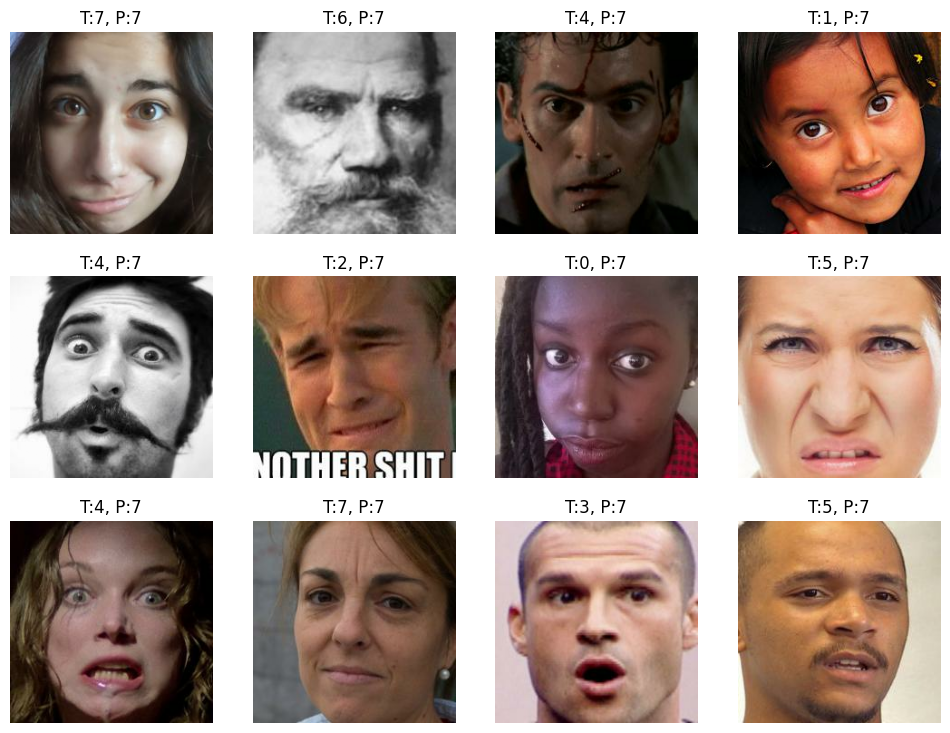

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch from test dataset
for x, y in test_ds.take(1):
    preds = model.predict(x)
    pred_labels = np.argmax(preds[0], axis=1)  # expression predictions
    true_labels = y["expression"].numpy()

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for i, ax in enumerate(axes.flat):
        img = x["image"][i].numpy()
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"T:{true_labels[i]}, P:{pred_labels[i]}")
    break


**Data Augmentation**

In [ ]:
!pip install keras-resnet


  Preparing metadata (setup.py) ... done
  Created wheel for keras-resnet: filename=keras_resnet-0.2.0-py2.py3-none-any.whl size=20453 sha256=3d5742a1e8d2766bb94bc9b26e8b50566f8e066a1aa7cf496f447fccbf3c51cd
  Stored in directory: /root/.cache/pip/wheels/36/74/0c/455526b8e61e6672988b0b06780a2c6aed3fd9605552c9d194
Successfully built keras-resnet


**Using **

In [ ]:
# ✅ ResNet-18 multitask model (Keras implementation) with fixed callbacks

import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# -------- ResNet-18 building blocks --------
def basic_block(x, filters, stride=1, name=None):
    shortcut = x
    y = layers.Conv2D(filters, 3, strides=stride, padding="same",
                      use_bias=False, kernel_initializer="he_normal",
                      name=(name + "_conv1" if name else None))(x)
    y = layers.BatchNormalization(name=(name + "_bn1" if name else None))(y)
    y = layers.Activation("relu")(y)

    y = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                      kernel_initializer="he_normal",
                      name=(name + "_conv2" if name else None))(y)
    y = layers.BatchNormalization(name=(name + "_bn2" if name else None))(y)

    if stride != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False,
                                 kernel_initializer="he_normal",
                                 name=(name + "_down_conv" if name else None))(x)
        shortcut = layers.BatchNormalization(name=(name + "_down_bn" if name else None))(shortcut)

    y = layers.Add()([y, shortcut])
    y = layers.Activation("relu")(y)
    return y

def make_layer(x, filters, blocks, stride=1, name=None):
    x = basic_block(x, filters, stride=stride, name=(name + "_b1" if name else None))
    for i in range(1, blocks):
        x = basic_block(x, filters, stride=1, name=(f"{name}_b{i+1}" if name else None))
    return x

def ResNet18_backbone(input_shape=(224,224,3)):
    inp = Input(shape=input_shape, name="resnet18_input")
    x = layers.ZeroPadding2D(3)(inp)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, kernel_initializer="he_normal", name="conv1")(x)
    x = layers.BatchNormalization(name="bn_conv1")(x)
    x = layers.Activation("relu")(x)
    x = layers.ZeroPadding2D(1)(x)
    x = layers.MaxPool2D(3, strides=2)(x)

    x = make_layer(x, 64, blocks=2, stride=1, name="conv2")
    x = make_layer(x, 128, blocks=2, stride=2, name="conv3")
    x = make_layer(x, 256, blocks=2, stride=2, name="conv4")
    x = make_layer(x, 512, blocks=2, stride=2, name="conv5")

    return Model(inputs=inp, outputs=x, name="resnet18_backbone")

# -------- Multitask ResNet-18 model --------
def build_multitask_resnet18(image_shape=(224,224,3), landmark_shape=(136,), use_augmentation=True):
    img_in = Input(shape=image_shape, name="image")
    if use_augmentation:
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.08),
            layers.RandomContrast(0.08),
        ], name="augmentation")
        x_img = aug(img_in)
    else:
        x_img = img_in

    backbone = ResNet18_backbone(image_shape)
    feat = backbone(x_img)
    feat = layers.GlobalAveragePooling2D()(feat)

    lm_in = Input(shape=landmark_shape, name="landmarks")
    l = layers.Dense(128, activation="relu")(lm_in)
    l = layers.Dropout(0.3)(l)
    l = layers.Dense(64, activation="relu")(l)

    merged = layers.Concatenate()([feat, l])
    merged = layers.Dense(256, activation="relu")(merged)
    merged = layers.Dropout(0.4)(merged)

    exp = layers.Dense(128, activation="relu")(merged)
    exp = layers.Dropout(0.3)(exp)
    exp_out = layers.Dense(8, activation="softmax", name="expression")(exp)

    va = layers.Dense(64, activation="relu")(merged)
    va = layers.Dropout(0.3)(va)
    va_out = layers.Dense(2, activation="tanh", name="va")(va)

    return Model(inputs=[img_in, lm_in], outputs=[exp_out, va_out]), backbone

# -------- Create model --------
model, backbone = build_multitask_resnet18()
model.summary()

# -------- Callbacks (FIXED with mode="max") --------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet18_multitask.keras",
        monitor="val_expression_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_expression_accuracy",
        factor=0.5,
        patience=3,
        verbose=1,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_expression_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1,
        mode="max"
    )
]

# -------- Stage 1: warmup training --------
backbone.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={"expression": "sparse_categorical_crossentropy", "va": "mse"},
    loss_weights={"expression": 2.0, "va": 1.0},
    metrics={"expression": ["accuracy"], "va": ["mse"]}
)

history = model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=callbacks)

# -------- Stage 2: fine-tuning --------
backbone.trainable = True
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={"expression": "sparse_categorical_crossentropy", "va": "mse"},
    loss_weights={"expression": 2.0, "va": 1.0},
    metrics={"expression": ["accuracy"], "va": ["mse"]}
)

history_ft = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

# -------- Final evaluation --------
results = model.evaluate(test_ds, verbose=1)
print("Test Results:", results)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ landmarks           │ (None, 136)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 128)       │     17,536 │ landmarks[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet18_backbone   │ (None, 7, 7, 512) │ 11,186,112 │ augmentation[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 128)       │          0 │ dense_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ resnet18_backbon… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 64)        │      8,256 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 576)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 256)       │    147,712 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 256)       │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 128)       │     32,896 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 64)        │     16,448 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 128)       │          0 │ dense_33[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 64)        │          0 │ dense_34[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expression (Dense)  │ (None, 8)         │      1,032 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ va (Dense)          │ (None, 2)         │        130 │ dropout_27[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,410,122 (43.53 MB)

 Trainable params: 11,400,522 (43.49 MB)

 Non-trainable params: 9,600 (37.50 KB)

Epoch 1/8
91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - expression_accuracy: 0.1068 - expression_loss: 12.7694 - loss: 26.4304 - va_loss: 0.8903 - va_mse: 0.8903 - val_expression_accuracy: 0.1255 - val_expression_loss: 2.0795 - val_loss: 4.3463 - val_va_loss: 0.1873 - val_va_mse: 0.1873 - learning_rate: 0.0010
Epoch 2/8
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - expression_accuracy: 0.1243 - expression_loss: 2.0819 - loss: 4.3477 - va_loss: 0.1838 - va_mse: 0.1838 - val_expression_accuracy: 0.1255 - val_expression_loss: 2.0795 - val_loss: 4.3393 - val_va_loss: 0.1803 - val_va_mse: 0.1803 - learning_rate: 0.0010
Epoch 3/8
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - expression_accuracy: 0.1218 - expression_loss: 2.0819 - loss: 4.3495 - va_loss: 0.1857 - va_mse: 0.1857 - val_expression_accuracy: 0.1255 - val_expression_loss: 2.0795 - val_loss: 4.3390 - val_va_loss: 0.1800 - val_va_mse: 0.1800 - learning_rate: 0.0010
Epoch 4/8
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - expression_accuracy: 0.1164

In [ ]:
# ✅ EfficientNetB0 multitask model with sample weights in tf.data.Dataset

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# -------- Multitask EfficientNetB0 model --------
def build_multitask_efficientnet(image_shape=(224,224,3), landmark_shape=(136,), use_augmentation=True):
    img_in = Input(shape=image_shape, name="image")
    if use_augmentation:
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.08),
            layers.RandomContrast(0.08),
        ], name="augmentation")
        x_img = aug(img_in)
    else:
        x_img = img_in

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False, input_tensor=x_img, weights="imagenet"
    )
    feat = layers.GlobalAveragePooling2D()(backbone.output)

    lm_in = Input(shape=landmark_shape, name="landmarks")
    l = layers.Dense(128, activation="relu")(lm_in)
    l = layers.Dropout(0.3)(l)
    l = layers.Dense(64, activation="relu")(l)

    merged = layers.Concatenate()([feat, l])
    merged = layers.Dense(256, activation="relu")(merged)
    merged = layers.Dropout(0.4)(merged)

    exp = layers.Dense(128, activation="relu")(merged)
    exp = layers.Dropout(0.3)(exp)
    exp_out = layers.Dense(8, activation="softmax", name="expression")(exp)

    va = layers.Dense(64, activation="relu")(merged)
    va = layers.Dropout(0.3)(va)
    va_out = layers.Dense(2, activation="tanh", name="va")(va)

    return Model(inputs=[img_in, lm_in], outputs=[exp_out, va_out]), backbone

# -------- Create model --------
model, backbone = build_multitask_efficientnet()
model.summary()

# -------- Compute class weights for expressions --------
labels_int = labels.astype(int)  # ensure integer type
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_int),
    y=labels_int
)
class_weight_dict = dict(enumerate(weights))
print("Class Weights:", class_weight_dict)

# Convert into per-sample weights
sample_weights_expr = np.array([class_weight_dict[l] for l in labels_int])

# -------- Add sample weights to tf.data.Dataset --------
def add_sample_weights(ds, sample_weights_array):
    """
    ds: tf.data.Dataset yielding ((images, landmarks), labels)
    sample_weights_array: numpy array of shape (num_samples,)
    """
    sample_weights_tensor = tf.constant(sample_weights_array, dtype=tf.float32)

    def map_fn(inputs, labels):
        img, lm = inputs
        idx = tf.cast(labels, tf.int32)
        weights = tf.gather(sample_weights_tensor, idx)
        return (img, lm), labels, weights

    return ds.map(map_fn)

train_ds_weighted = add_sample_weights(train_ds, sample_weights_expr)
val_ds_weighted = add_sample_weights(val_ds, sample_weights_expr)  # optional

# -------- Callbacks --------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_efficientnetb0_multitask.keras",
        monitor="val_expression_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_expression_accuracy",
        factor=0.5,
        patience=3,
        verbose=1,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_expression_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1,
        mode="max"
    )
]

# -------- Stage 1: warmup training --------
backbone.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={"expression": "sparse_categorical_crossentropy", "va": "mse"},
    loss_weights={"expression": 2.0, "va": 1.0},
    metrics={"expression": ["accuracy"], "va": ["mse"]}
)

history = model.fit(
    train_ds_weighted,
    validation_data=val_ds_weighted,
    epochs=8,
    callbacks=callbacks
)

# -------- Stage 2: fine-tuning --------
backbone.trainable = True
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={"expression": "sparse_categorical_crossentropy", "va": "mse"},
    loss_weights={"expression": 2.0, "va": 1.0},
    metrics={"expression": ["accuracy"], "va": ["mse"]}
)

history_ft = model.fit(
    train_ds_weighted,
    validation_data=val_ds_weighted,
    epochs=20,
    callbacks=callbacks
)

# -------- Final evaluation --------
results = model.evaluate(test_ds, verbose=1)
print("Test Results:", results)


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,470,189 (17.05 MB)

 Trainable params: 4,428,166 (16.89 MB)

 Non-trainable params: 42,023 (164.16 KB)

Class Weights: {0: np.float64(0.99975), 1: np.float64(0.99975), 2: np.float64(0.99975), 3: np.float64(0.99975), 4: np.float64(0.99975), 5: np.float64(0.99975), 6: np.float64(0.99975), 7: np.float64(1.001753507014028)}


TypeError: in user code:

    File "/tmp/ipython-input-3731665208.py", line 73, in map_fn  *
        idx = tf.cast(labels, tf.int32)

    TypeError: Expected any non-tensor type, but got a tensor instead.
